# House Price Model Improvement

## Project Overview

This is my eighth Python machine learning project.

In this project, I improve the house price regression model using advanced feature engineering, outlier handling, XGBoost, LightGBM, and hyperparameter tuning.

The goal is to improve the previous regression project and build a stronger machine learning workflow.

Main tasks:

- Load the House Prices dataset
- Analyze and remove outliers
- Create stronger house-related features
- Build preprocessing pipelines
- Compare multiple regression models
- Tune model hyperparameters
- Evaluate model performance using RMSE
- Generate a Kaggle submission file

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")

try:
    from xgboost import XGBRegressor
    xgboost_available = True
except ImportError:
    xgboost_available = False
    print("XGBoost is not installed.")

try:
    from lightgbm import LGBMRegressor
    lightgbm_available = True
except ImportError:
    lightgbm_available = False
    print("LightGBM is not installed")
    

In [43]:
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [44]:
train = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")

train.head()

test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [45]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.info()

train["SalePrice"].describe()

Train Shape: (1460, 81)
Test Shape: (1459, 80)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  Overa

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

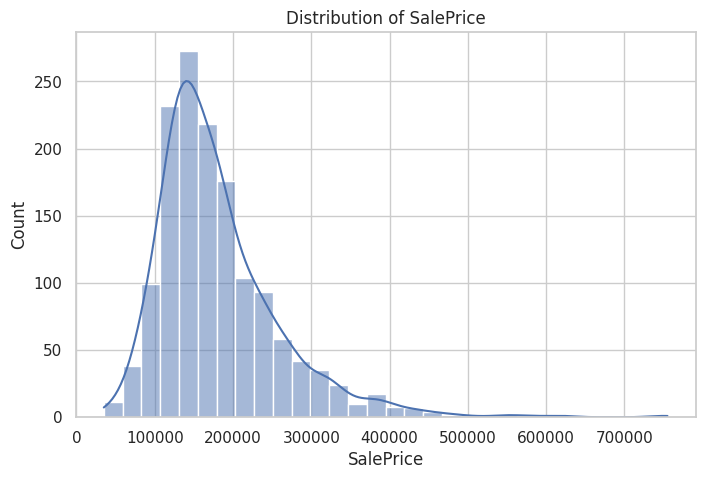

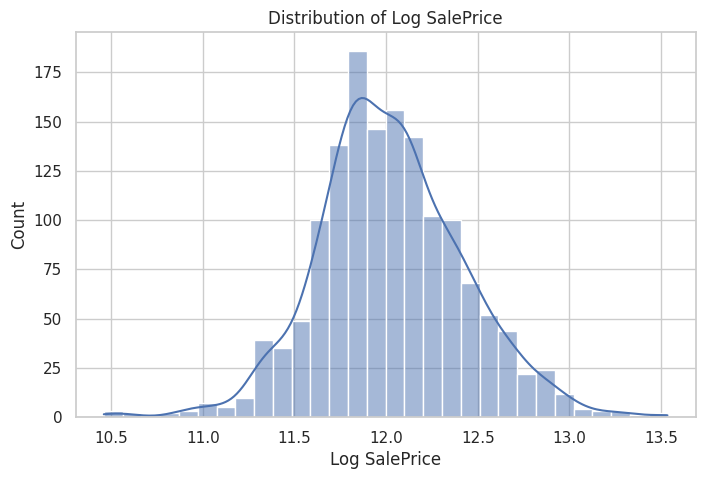

In [46]:
plt.figure(figsize=(8, 5))

sns.histplot(train["SalePrice"], bins=30, kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

train["SalePrice_Log"] = np.log1p(train["SalePrice"])

plt.figure(figsize=(8, 5))

sns.histplot(train["SalePrice_Log"], bins=30, kde=True)

plt.title("Distribution of Log SalePrice")
plt.xlabel("Log SalePrice")
plt.ylabel("Count")
plt.show()

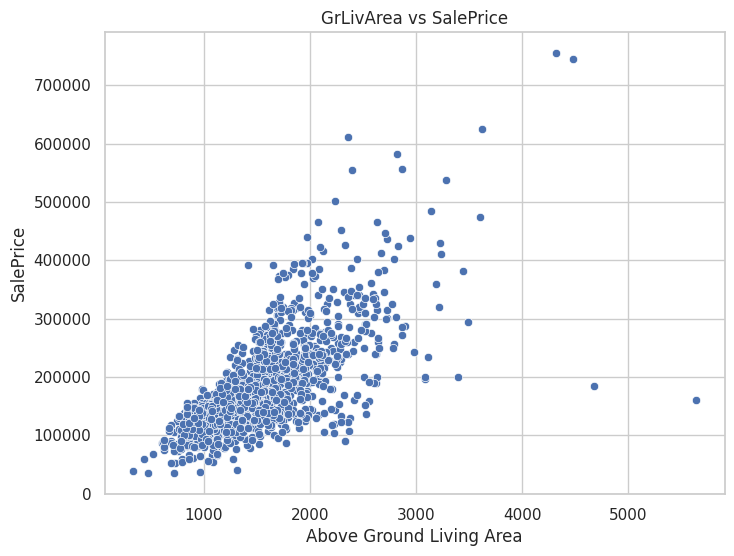

In [47]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=train,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("GrLivArea vs SalePrice")
plt.xlabel("Above Ground Living Area")
plt.ylabel("SalePrice")
plt.show()

Original train shape: (1460, 82)
Cleaned train shape: (1458, 82)


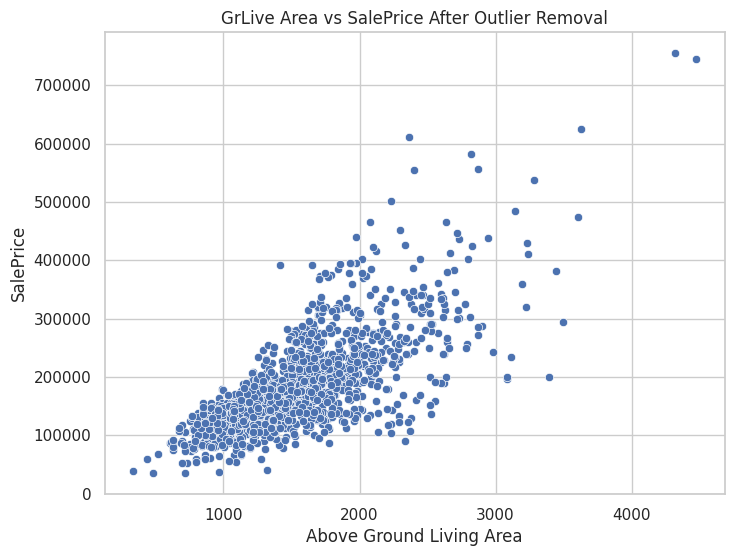

In [48]:
train_clean = train.drop(
    train[
        (train["GrLivArea"] > 4000) &
        (train["SalePrice"] < 300000) 
    ].index
)

print("Original train shape:", train.shape)
print("Cleaned train shape:", train_clean.shape)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=train_clean,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("GrLive Area vs SalePrice After Outlier Removal")
plt.xlabel("Above Ground Living Area")
plt.ylabel("SalePrice")
plt.show()

In [49]:
missing_percent = (train_clean.isnull().sum() / len(train_clean) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": train_clean.isnull().sum(),
    "Missing Percentage": missing_percent
}).sort_values("Missing Values", ascending=False)

missing_summary[missing_summary["Missing Values"] > 0].head(20)

,Missing Values,Missing Percentage
PoolQC,1452,99.59
MiscFeature,1404,96.30
Alley,1367,93.76
Fence,1177,80.73
MasVnrType,872,59.81
FireplaceQu,690,47.33
LotFrontage,259,17.76
GarageQual,81,5.56
GarageYrBlt,81,5.56
GarageFinish,81,5.56


In [50]:
def create_features(df):
    df = df.copy()
    
    # Fill missing numeric area columns with 0 before creating new features
    area_cols = ["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "GarageArea", "WoodDeckSF", "OpenPorchSF"]
    for col in area_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    
    bath_cols = ["FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath"]
    for col in bath_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    
    # Total square footage
    df["TotalSF"] = df[["TotalBsmtSF", "1stFlrSF", "2ndFlrSF"]].fillna(0).sum(axis=1)
    
    # Total bathrooms
    df["TotalBathrooms"] = (
        df["FullBath"] 
        + 0.5 * df["HalfBath"] 
        + df["BsmtFullBath"] 
        + 0.5 * df["BsmtHalfBath"]
    )
    
    # House age when sold
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    
    # Years since remodeling
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    
    # Total porch and deck area
    df["TotalPorchSF"] = (
        df["WoodDeckSF"] 
        + df["OpenPorchSF"] 
        + df["EnclosedPorch"].fillna(0)
        + df["3SsnPorch"].fillna(0)
        + df["ScreenPorch"].fillna(0)
    )
    
    # Binary features
    df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
    df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
    df["HasPool"] = (df["PoolArea"] > 0).astype(int)
    df["WasRemodeled"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)
    
    # Quality combinations
    df["OverallQual_GrLivArea"] = df["OverallQual"] * df["GrLivArea"]
    df["OverallQual_TotalSF"] = df["OverallQual"] * df["TotalSF"]
    
    return df

In [51]:
train_fe = create_features(train_clean)
test_fe = create_features(test)

train_fe.head()

print("train_fe exists:", "train_fe" in globals())
print("test_fe exists:", "test_fe" in globals())

print("train_fe shape:", train_fe.shape)
print("test_fe shape:", test_fe.shape)

train_fe exists: True
test_fe exists: True
train_fe shape: (1458, 94)
test_fe shape: (1459, 92)


In [52]:
X = train_fe.drop(columns=["SalePrice", "SalePrice_Log"])
y = train_fe["SalePrice_Log"]

X_test = test_fe.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (1458, 92)
y shape: (1458,)
X_test shape: (1459, 92)


In [53]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 49
Categorical features: 43


In [54]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

X_train shape: (1166, 92)
X_valid shape: (292, 92)


In [55]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [56]:
def evaluate_model(model, model_name):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions_log = pipeline.predict(X_valid)

    rmse = np.sqrt(mean_squared_error(y_valid, predictions_log))
    mae = mean_absolute_error(y_valid, predictions_log)
    r2 = r2_score(y_valid, predictions_log)

    return {
        "Model": model_name,
        "RMSE_Log": rmse, 
        "MAE_Log": mae,
        "R2_Score": r2,
        "Pipeline": pipeline
    }

In [57]:
models = [
    (Ridge(alpha=10), "Ridge Regression"),
    (RandomForestRegressor(n_estimators=300, random_state=42), "Random Forest"),
    (GradientBoostingRegressor(random_state=42), "Gradient Boosting")
]

if xgboost_available:
    models.append((
        XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=3,
            subsmaple=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective="reg:squarederror"
        ),
        "XGBoost"
    ))

if lightgbm_available:
    models.append((
        LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            random_state=42
        ),
        "LightGBM"
    ))

results = []

for model, model_name in models:
    result = evaluate_model(model, model_name)
    results.append(result)

model_results = pd.DataFrame([
    {
        "Model": result["Model"],
        "RMSE_Log": result["RMSE_Log"],
        "MAE_Log": result["MAE_Log"],
        "R2_Score": result["R2_Score"]
    }
    for result in results
]).sort_values("RMSE_Log")

model_results

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:51:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "subsmaple" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001077 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4646
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 190
[LightGBM] [Info] Start training from score 12.023362


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,RMSE_Log,MAE_Log,R2_Score
3,XGBoost,0.119540,0.083725,0.915232
0,Ridge Regression,0.122371,0.085576,0.911169
2,Gradient Boosting,0.128325,0.089253,0.902315
4,LightGBM,0.132377,0.087785,0.896049
1,Random Forest,0.139683,0.093231,0.884258


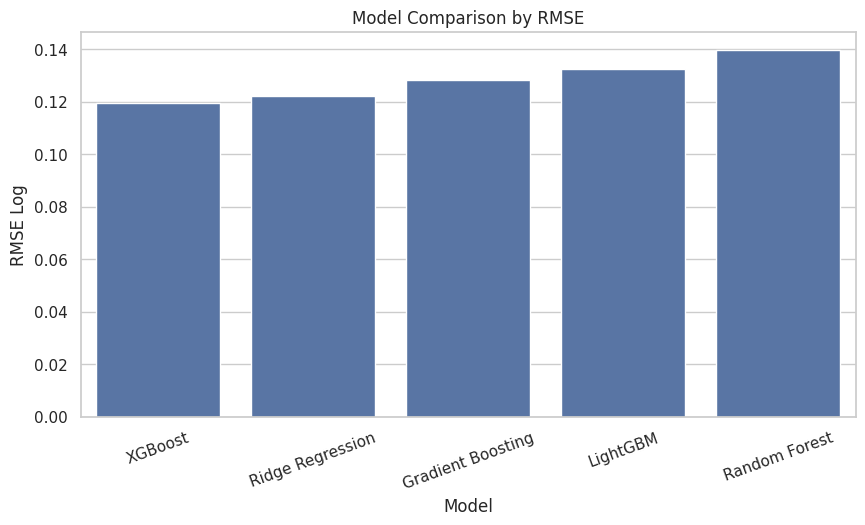

In [58]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=model_results,
    x="Model",
    y="RMSE_Log"
)

plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE Log")
plt.xticks(rotation=20)
plt.show()

## Insight

The model with the lowest RMSE_Log is the best model in this comparison.
Lower RMSE means the model makes smaller prediction errors.

In [59]:
best_model_name = model_results.iloc[0]["Model"]

print("Best model from validation set:", best_model_name)



Best model from validation set: XGBoost


In [60]:
if best_model_name == "XGBoost" and xgboost_available:
    best_model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror"
    )

elif best_model_name =="LightGBM" and lightgbm_available:
    best_model = LGMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42
    )

elif best_model_name == "Random Forest":
    best_model = RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )
elif best_model_name == "Gradient Boosting":
    best_model = GradientBoostingRegressor(
        random_state=42
    )

else:
    best_model = Ridge(alpha=10)

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

cv_scores = cross_val_score(
    best_pipeline,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores

print("CV RMSE scores:", cv_rmse)
print("Mean CV RMSE:", cv_rmse.mean())
print("Std CV RMSE:", cv_rmse.std())

CV RMSE scores: [0.11237386 0.11845123 0.12428352 0.10558794 0.11502668]
Mean CV RMSE: 0.11514464570496016
Std CV RMSE: 0.006220518792638456


In [61]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.7, 0.8, 0.9, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Id',
                                                                                'MSSubClass',
                                                                                'LotFrontage',
                                                                                'LotArea',
                                                                                'OverallQual',
                                                                                'OverallCond',
                                                                                'YearBuilt',
                                                                                'YearRemodAdd',
                                                                                'MasVnrArea',
                                                                                'BsmtFinSF1',
                                                                                'BsmtFinSF2',
                                                                                'BsmtUnfSF',
                                                                                'Tota...
                                              GradientBoostingRegressor(random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [2, 3, 4],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                500],
                                        'model__subsample': [0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [62]:
print("Best parameters:")
print(gb_search.best_params_)

print("\nBest CV RMSE:")
print(-gb_search.best_score_)

Best parameters:
{'model__subsample': 0.7, 'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 4, 'model__learning_rate': 0.03}

Best CV RMSE:
0.11709013700818358


In [63]:
tuned_model = gb_search.best_estimator_

valid_predictions_log = tuned_model.predict(X_valid)

valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_predictions_log))
valid_mae = mean_absolute_error(y_valid, valid_predictions_log)
valid_r2 = r2_score(y_valid, valid_predictions_log)

print(f"Tuned Model RMSE Log: {valid_rmse:.4f}")
print(f"Tuned Model MAE Log: {valid_mae:.4f}")
print(f"Tuned Model R2 Score: {valid_r2:.4f}")

Tuned Model RMSE Log: 0.1232
Tuned Model MAE Log: 0.0839
Tuned Model R2 Score: 0.9100


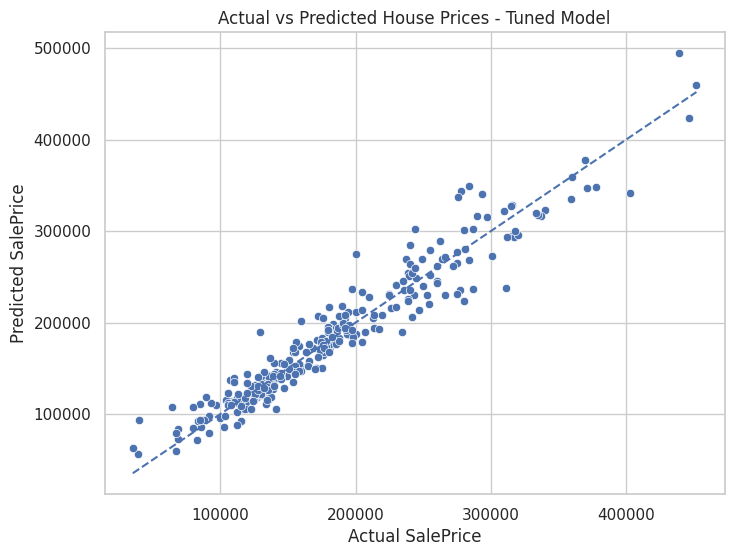

In [64]:
valid_actual_price = np.expm1(y_valid)
valid_predicted_price = np.expm1(valid_predictions_log)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=valid_actual_price,
    y=valid_predicted_price
)

plt.plot(
    [valid_actual_price.min(), valid_actual_price.max()],
    [valid_actual_price.min(), valid_actual_price.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices - Tuned Model")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.show()

In [65]:
final_model = gb_search.best_estimator_

final_model.fit(X, y)

print("Final tuned model trained on full training data.")

Final tuned model trained on full training data.


In [66]:
test_predictions_log = final_model.predict(X_test)

test_predictions = np.expm1(test_predictions_log)

test_predictions[:10]

array([124060.37515072, 164094.17348488, 173224.62078569, 189557.92529631,
       179245.11349835, 174130.1387611 , 182579.40602114, 168684.63873257,
       183497.49617209, 125033.3766968 ])

In [67]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": test_predictions
})

submission.head()

,Id,SalePrice
0,1461,124060.375151
1,1462,164094.173485
2,1463,173224.620786
3,1464,189557.925296
4,1465,179245.113498


In [68]:
submission.to_csv("/kaggle/working/house_price_improved_submission.csv", index=False)

print("Improved house price submission file created successfully.")

Improved house price submission file created successfully.


In [69]:
from IPython.display import FileLink

FileLink("/kaggle/working/house_price_improved_submission.csv")

/kaggle/working/house_price_improved_submission.csv

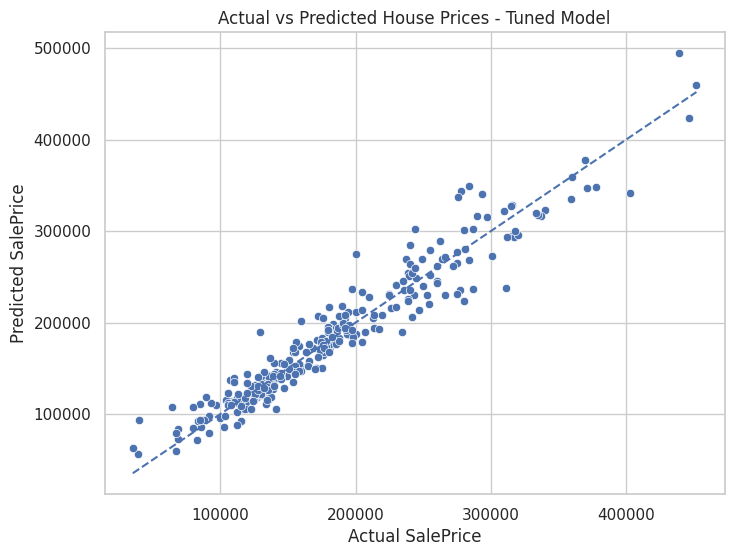

In [70]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=valid_actual_price,
    y=valid_predicted_price
)

plt.plot(
    [valid_actual_price.min(), valid_actual_price.max()],
    [valid_actual_price.min(), valid_actual_price.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices - Tuned Model")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")

plt.savefig("/kaggle/working/house_price_improved_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

## Key Findings

From this house price model improvement project, I found that:

1. Removing extreme outliers helped the model learn the main price pattern more clearly.
2. TotalSF is an important feature because it represents total usable house area.
3. Feature engineering improved the dataset by creating stronger predictors such as TotalSF, TotalBathrooms, HouseAge, RemodAge, HasGarage, and OverallQual_TotalSF.
4. XGBoost and LightGBM are strong gradient boosting models for regression problems.
5. RandomizedSearchCV helped tune Gradient Boosting hyperparameters.
6. RMSE is useful for comparing regression models because lower RMSE means smaller prediction error.
7. The tuned model can generate an improved Kaggle submission file.

## What I Learned

In this project, I practiced:

- Outlier detection
- Outlier removal
- Advanced feature engineering
- Regression model comparison
- XGBoost and LightGBM
- Hyperparameter tuning
- Cross-validation
- Actual vs predicted analysis
- Kaggle submission workflow

## Next Step

The next step is to learn model deployment and build a simple app that predicts house prices from user input.